# Importar bibliotecas, carregar e transformar os dados

In [1]:
# Instala os pacotes Python necessários via pip

# Usa o comando 'pip' para instalar os pacotes
# A flag '-q' significa 'quiet': suprime a maior parte da saída, deixando a instalação menos verbosa
# Estamos instalando os seguintes pacotes:
# - 'evaluate': biblioteca de métricas de avaliação de modelos
# - 'transformers': biblioteca da Hugging Face com modelos pré-treinados, aqui usada para visão computacional (ViT)
# - 'datasets': facilita o carregamento e o processamento de conjuntos de dados
# - 'mlflow': plataforma open source para gerenciar o ciclo de vida de machine learning (experimentos, empacotamento e deploy)

# Observação: antes de rodar, garanta que Python e pip estejam instalados.
# Também é necessária conexão com a internet, porque o pip baixa os pacotes do PyPI.
!pip install -U -q evaluate transformers datasets>=2.14.5 accelerate>=0.27 mlflow 2>/dev/null

In [2]:
# Importação das bibliotecas e módulos necessários
import warnings  # módulo de tratamento de avisos
warnings.filterwarnings("ignore")  # ignora os avisos durante a execução

import gc  # módulo de coleta de lixo
import numpy as np  # NumPy, para operações numéricas
import pandas as pd  # Pandas, para manipulação de dados
import itertools  # 'itertools', para iteradores e laços
from collections import Counter  # 'Counter', para contagem de elementos
import matplotlib.pyplot as plt  # Matplotlib, para visualização de dados
from sklearn.metrics import (  # métricas do scikit-learn
    accuracy_score,  # para calcular a acurácia
    roc_auc_score,  # para o ROC AUC
    confusion_matrix,  # para a matriz de confusão
    classification_report,  # para o relatório de classificação
    f1_score  # para o F1-score
)

# Importação de módulos e classes específicos do projeto
from imblearn.over_sampling import RandomOverSampler  # importa o RandomOverSampler
import accelerate  # módulo 'accelerate'
import evaluate  # módulo 'evaluate'
from datasets import Dataset, Image, ClassLabel  # classes 'Dataset', 'ClassLabel' e 'Image'
from transformers import (  # módulos da biblioteca Transformers
    TrainingArguments,  # argumentos de treino
    Trainer,  # treinamento do modelo
    ViTImageProcessor,  # processamento de imagens para modelos ViT
    ViTForImageClassification,  # modelo ViT para classificação de imagens
    DefaultDataCollator  # colação padrão dos dados
)
import torch  # PyTorch, para deep learning
from torch.utils.data import DataLoader  # criação dos data loaders
from torchvision.transforms import (  # funções de transformação de imagem
    CenterCrop,  # recorte central da imagem
    Compose,  # encadeia varias transformações
    Normalize,  # normaliza os valores dos pixels
    RandomRotation,  # rotação aleatória
    RandomResizedCrop,  # recorte e redimensionamento aleatórios
    RandomHorizontalFlip,  # espelhamento horizontal aleatório
    RandomAdjustSharpness,  # ajuste aleatório de nitidez
    Resize,  # redimensionamento
    ToTensor  # converte as imagens em tensores do PyTorch
)

In [3]:
# Importa o módulo necessário da biblioteca PIL (Python Imaging Library).
from PIL import ImageFile

# Habilita o carregamento de imagens truncadas.
# Com isso o PIL tenta abrir imagens mesmo que estejam corrompidas ou incompletas.
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [4]:
# Carrega as imagens a partir da estrutura de pastas do projeto

# Importa as bibliotecas necessárias
image_dict = {}

# Define a lista de nomes de arquivo
from pathlib import Path
from tqdm import tqdm
import os
# Inicializa listas vazias para guardar os caminhos e os rótulos
file_names = []
labels = []

# Percorre todos os arquivos de imagem do diretório informado
for file in sorted((Path('../dataset/').glob('*/*/*.*'))):
    label = file.parent.name  # extrai o rótulo a partir do nome da pasta (FAKE ou REAL)
    labels.append(label)  # adiciona o rótulo à lista
    file_names.append(str(file))  # adiciona o caminho à lista

# Exibe o total de arquivos e de rótulos coletados
print(len(file_names), len(labels))

# Monta um DataFrame do pandas com os caminhos e rótulos coletados
df = pd.DataFrame.from_dict({"image": file_names, "label": labels})
print(df.shape)

120000 120000
(120000, 2)


In [5]:
df.head()

,image,label
0,../dataset/train/FAKE/0 (1).jpg,FAKE
1,../dataset/train/FAKE/0 (1).jpg,FAKE
2,../dataset/train/FAKE/0 (1).jpg,FAKE
3,../dataset/train/FAKE/0 (1).jpg,FAKE
4,../dataset/train/FAKE/0 (1).jpg,FAKE


In [6]:
df['label'].unique()

array(['FAKE', 'REAL'], dtype=object)

In [8]:
# Cria um Dataset a partir do DataFrame do pandas.
dataset = Dataset.from_pandas(df).cast_column("image", Image())

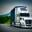

In [9]:
# Exibe a primeira imagem do conjunto de dados
dataset[0]["image"]

In [10]:
# Extrai um subconjunto da lista 'labels' usando fatiamento.
# A sintaxe [:5] seleciona do inicio ate o quinto elemento (sem incluir o índice 5).
# Isso devolve os 5 primeiros elementos da lista 'labels'.
# O resultado e uma nova lista com esses elementos.
labels_subset = labels[:5]

# Exibe o subconjunto de rótulos para inspecionar o conteudo.
print(labels_subset)

['FAKE', 'FAKE', 'FAKE', 'FAKE', 'FAKE']


In [11]:
# Cria a lista de rótulos únicos
labels_list = ['REAL', 'FAKE'] #list(set(labels))

# Inicializa os dicionários que mapeiam rótulo para ID e vice-versa
label2id, id2label = dict(), dict()

# Percorre os rótulos únicos atribuindo um ID a cada um, e o inverso
for i, label in enumerate(labels_list):
    label2id[label] = i  # mapeia o rótulo para o ID correspondente
    id2label[i] = label  # mapeia o ID para o rótulo correspondente

# Exibe os dicionários resultantes para referência
print("Mapeamento de IDs para rótulos:", id2label, '\n')
print("Mapeamento de rótulos para IDs:", label2id)

Mapeamento de IDs para rótulos: {0: 'REAL', 1: 'FAKE'} 

Mapeamento de rótulos para IDs: {'REAL': 0, 'FAKE': 1}


In [12]:
# Cria os ClassLabels para associar rótulos aos IDs
ClassLabels = ClassLabel(num_classes=len(labels_list), names=labels_list)

# Mapeia os rótulos para IDs
def map_label2id(example):
    example['label'] = ClassLabels.str2int(example['label'])
    return example

dataset = dataset.map(map_label2id, batched=True)

# Converte a coluna de rótulo para o tipo ClassLabel
dataset = dataset.cast_column('label', ClassLabels)

# Divide o conjunto em treino e teste na proporção 60-40. ATENÇÃO: isso descarta a divisão canonica do CIFAKE e pode inflar a métrica, ja que o modelo base foi treinado nesse mesmo dataset.
dataset = dataset.train_test_split(test_size=0.4, shuffle=True, stratify_by_column="label")

# Extrai a parte de treino do conjunto dividido.
train_data = dataset['train']

# Extrai a parte de teste do conjunto dividido.
test_data = dataset['test']

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/120000 [00:00<?, ? examples/s]

In [13]:
# Define o identificador do modelo ViT pré-treinado
model_str = "../model/ai_vs_real_image_detection"

# Cria o processador de entrada do ViT a partir do modelo pré-treinado
processor = ViTImageProcessor.from_pretrained(model_str)

# Obtém a média e o desvio padrão usados na normalização das imagens
image_mean, image_std = processor.image_mean, processor.image_std

# Obtém o tamanho (altura) das imagens de entrada do ViT
size = processor.size["height"]
print("Tamanho: ", size)

# Define a transformação de normalização das imagens de entrada
normalize = Normalize(mean=image_mean, std=image_std)

# Define o conjunto de transformações dos dados de treino
_train_transforms = Compose(
    [
        Resize((size, size)),  # redimensiona para o tamanho de entrada do ViT
        RandomRotation(90),  # rotação aleatória
        RandomAdjustSharpness(2),  # ajuste aleatório de nitidez
        ToTensor(),  # converte para tensores
        normalize  # normaliza com média e desvio padrão
    ]
)

# Define o conjunto de transformações dos dados de validação
_val_transforms = Compose(
    [
        Resize((size, size)),  # redimensiona para o tamanho de entrada do ViT
        ToTensor(),  # converte para tensores
        normalize  # normaliza com média e desvio padrão
    ]
)

# Função que aplica as transformações de treino a um lote de exemplos
def train_transforms(examples):
    examples['pixel_values'] = [_train_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

# Função que aplica as transformações de validação a um lote de exemplos
def val_transforms(examples):
    examples['pixel_values'] = [_val_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

preprocessor_config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

Tamanho:  224


In [14]:
# Aplica as transformações aos dados de treino
train_data.set_transform(train_transforms)

# Aplica as transformações aos dados de teste/validação
test_data.set_transform(val_transforms)

In [15]:
# Função de colação que prepara os lotes para o treino do modelo.
def collate_fn(examples):
    # Empilha os valores de pixel dos exemplos em um único tensor.
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    
    # Converte os rótulos dos exemplos em IDs numéricos usando o dicionário label2id.
    labels = torch.tensor([example['label'] for example in examples])
    
    # Devolve um dicionário com os pixels e os rótulos do lote.
    return {"pixel_values": pixel_values, "labels": labels}

# Carregar, treinar e avaliar o modelo

In [16]:
# Cria o modelo ViTForImageClassification a partir de um checkpoint pré-treinado, com o número de rótulos de saída definido.
model = ViTForImageClassification.from_pretrained(model_str, num_labels=len(labels_list))

# Configura o mapeamento entre rótulos de classe e seus indices.
model.config.id2label = id2label
model.config.label2id = label2id

# Calcula e exibe a quantidade de parâmetros treináveis do modelo, em milhões.
print(model.num_parameters(only_trainable=True) / 1e6)

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

85.800194


In [17]:
# Carrega a métrica de acurácia da biblioteca 'evaluate'
accuracy = evaluate.load("accuracy")

# Define a função 'compute_metrics' para calcular as métricas de avaliação
def compute_metrics(eval_pred):
    # Extrai as previsões do objeto de avaliação
    predictions = eval_pred.predictions
    
    # Extrai os rótulos verdadeiros do objeto de avaliação
    label_ids = eval_pred.label_ids
    
    # Calcula a acurácia usando a métrica carregada
    # Converte as previsões em rótulos escolhendo a classe de maior probabilidade (argmax)
    predicted_labels = predictions.argmax(axis=1)
    
    # Calcula a acurácia comparando os rótulos previstos com os verdadeiros
    acc_score = accuracy.compute(predictions=predicted_labels, references=label_ids)['accuracy']
    
    # Devolve a acurácia calculada em um dicionário com a chave "accuracy"
    return {
        "accuracy": acc_score
    }

In [18]:
# Define o nome da métrica usada durante o treino e a avaliação.
metric_name = "accuracy"

# Define o nome do modelo, usado para criar o diretório dos checkpoints e das saídas.
model_name = "ai_vs_real_image_detection"

# Define a quantidade de épocas de treino.
num_train_epochs = 2

# Cria a instância de TrainingArguments com as configurações de treino.
args = TrainingArguments(
    # Diretório onde os checkpoints e as saídas serão salvos.
    output_dir=model_name,
    
    # Estratégia de avaliação, executada ao final de cada época.
    eval_strategy="epoch",
    
    # Taxa de aprendizado do otimizador.
    learning_rate=1e-6,
    
    # Tamanho do lote de treino por dispositivo.
    per_device_train_batch_size=64,
    
    # Tamanho do lote de avaliação por dispositivo.
    per_device_eval_batch_size=32,
    
    # Número total de épocas de treino.
    num_train_epochs=num_train_epochs,
    
    # Aplica decaimento de peso para reduzir o sobreajuste.
    weight_decay=0.02,
    
    # Número de passos de aquecimento do agendador da taxa de aprendizado.
    warmup_steps=50,
    
    # Desativa a remoção automática de colunas não utilizadas do dataset.
    remove_unused_columns=False,
    
    # Estratégia de gravação dos checkpoints (aqui, a cada época).
    save_strategy='epoch',
    
    # Carrega o melhor modelo ao final do treino.
    load_best_model_at_end=True,
    
    # Limita a quantidade de checkpoints salvos para economizar espaço.
    save_total_limit=1,
    
    # Desativa o envio do progresso de treino para serviços externos.
    report_to="none"  # sem envio de logs
)

In [19]:
# Cria a instância do Trainer para o ajuste fino do modelo de visão.

# - `model`: o modelo pré-treinado que será ajustado.
# - `args`: configurações e hiperparâmetros do treino.
# - `train_dataset`: conjunto usado para treinar o modelo.
# - `eval_dataset`: conjunto usado para avaliar o modelo durante o treino.
# - `data_collator`: função que define como os lotes são montados e processados.
# - `compute_metrics`: função que calcula as métricas de avaliação.
# - `processing_class`: o processador de imagens do ViT.

trainer = Trainer(
    model,
    args,
    train_dataset=train_data,
    eval_dataset=test_data,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    processing_class=processor,
)

In [20]:
# Avalia o desempenho do modelo antes do treino, sobre o conjunto de teste.
# A função calcula métricas como acurácia e perda,
# para medir o desempenho em dados não vistos.

trainer.evaluate()

{'eval_loss': 0.04503990337252617,
 'eval_model_preparation_time': 0.0034,
 'eval_acurácia': 0.9835208333333333,
 'eval_runtime': 625.7087,
 'eval_samples_per_second': 76.713,
 'eval_steps_per_second': 2.397}

In [21]:
# Inicia o treino do modelo pelo objeto trainer.
trainer.train()

Epoch,Training Loss,Validation Loss,Model Preparation Time,Accuracy
1,0.034900,0.043976,0.003400,0.983729
2,0.032700,0.042960,0.003400,0.984292


TrainOutput(global_step=2250, training_loss=0.03694852489895291, metrics={'train_runtime': 4259.8283, 'train_samples_per_second': 33.804, 'train_steps_per_second': 0.528, 'total_flos': 1.1158846504501248e+19, 'train_loss': 0.03694852489895291, 'epoch': 2.0})

In [22]:
# Avalia o desempenho do modelo depois do treino, sobre o conjunto de validação ou teste.
# A função calcula métricas de avaliação como acurácia e perda
# e dá uma noção de quao bem o modelo está desempenhando.

trainer.evaluate()

{'eval_loss': 0.04296007752418518,
 'eval_model_preparation_time': 0.0034,
 'eval_acurácia': 0.9842916666666667,
 'eval_runtime': 388.2294,
 'eval_samples_per_second': 123.638,
 'eval_steps_per_second': 3.864,
 'epoch': 2.0}

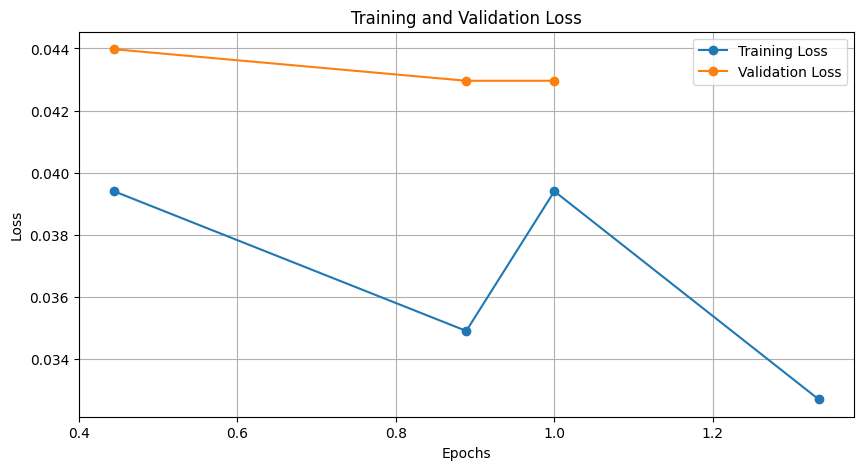

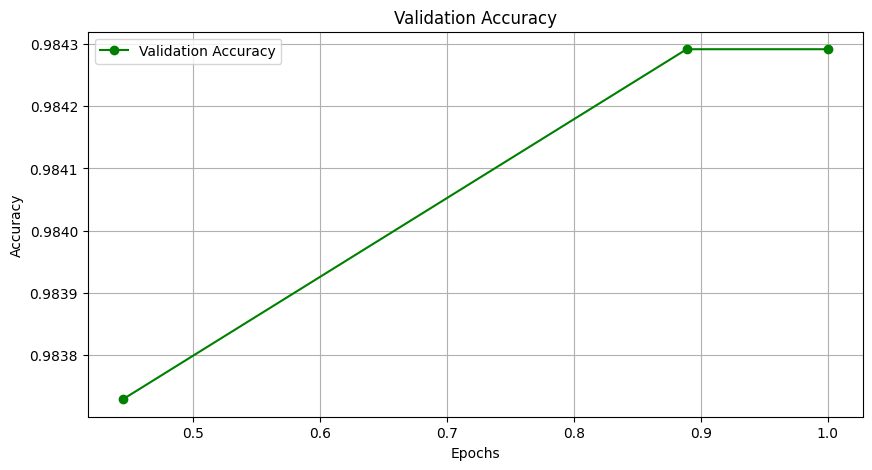

In [44]:
import matplotlib.pyplot as plt

# Extrai os logs do estado do trainer
history = trainer.state.log_history

# Separa os valores de época, perda e acurácia
epochs = []
train_losses = []
eval_losses = []
accuracies = []

for log in history:
    if "epoch" in log:
        epochs.append(log["epoch"])
    if "loss" in log:
        train_losses.append(log["loss"])
    if "eval_loss" in log:
        eval_losses.append(log["eval_loss"])
    if "eval_accuracy" in log:
        accuracies.append(log["eval_accuracy"])

# Plota a perda de treino e de validação
plt.figure(figsize=(10, 5))
plt.plot(epochs[:len(train_losses)], train_losses, label="Perda de treino", marker='o')
plt.plot(epochs[:len(eval_losses)], eval_losses, label="Perda de validação", marker='o')
plt.xlabel("Épocas")
plt.ylabel("Perda")
plt.title("Perda de treino e de validação")
plt.legend()
plt.grid()
plt.show()

# Plota a acurácia
plt.figure(figsize=(10, 5))
plt.plot(epochs[:len(accuracies)], accuracies, label="Acurácia de validação", marker='o', color='green')
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.title("Acurácia de validação")
plt.legend()
plt.grid()
plt.show()


In [23]:
# Usa o 'trainer' treinado para prever sobre 'test_data'.
outputs = trainer.predict(test_data)

# Exibe as métricas obtidas nas previsões.
print(outputs.metrics)

{'test_loss': 0.04296007752418518, 'test_model_preparation_time': 0.0034, 'test_accuracy': 0.9842916666666667, 'test_runtime': 387.1409, 'test_samples_per_second': 123.986, 'test_steps_per_second': 3.875}


Acurácia: 0.9843
F1-score: 0.9843


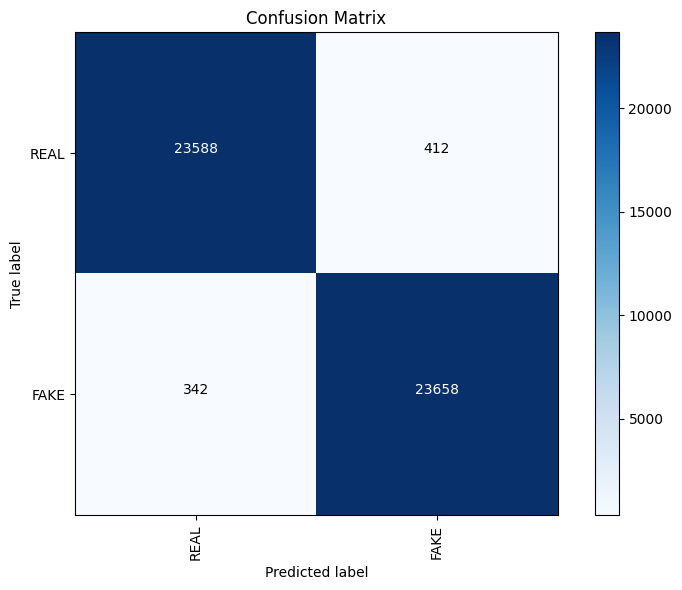


Relatório de classificação:

              precision    recall  f1-score   support

        REAL     0.9857    0.9828    0.9843     24000
        FAKE     0.9829    0.9858    0.9843     24000

    accuracy                         0.9843     48000
   macro avg     0.9843    0.9843    0.9843     48000
weighted avg     0.9843    0.9843    0.9843     48000



In [24]:
# Extrai os rótulos verdadeiros das saídas do modelo
y_true = outputs.label_ids

# Define os rótulos previstos escolhendo a classe de maior probabilidade
y_pred = outputs.predictions.argmax(1)

# Função que plota a matriz de confusão
def plot_confusion_matrix(cm, classes, title='Matriz de confusão', cmap=plt.cm.Blues, figsize=(10, 8)):
    """
    Plota a matriz de confusão.

    Parâmetros:
        cm (array): matriz de confusão devolvida por sklearn.metrics.confusion_matrix.
        classes (list): lista com os nomes das classes, por exemplo ['REAL', 'FAKE'].
        title (str): título do gráfico.
        cmap (colormap do matplotlib): mapa de cores usado no gráfico.
    """
    # Cria a figura com o tamanho definido
    plt.figure(figsize=figsize)
    
    # Exibe a matriz de confusão como imagem, com mapa de cores
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    # Define as marcações e os rótulos das classes nos eixos
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    fmt = '.0f'
    # Adiciona os valores numéricos dentro das células do gráfico
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    # Rotula os eixos
    plt.ylabel('Rótulo verdadeiro')
    plt.xlabel('Rótulo previsto')

    # Ajusta o layout do gráfico
    plt.tight_layout()
    # Exibe o gráfico
    plt.show()

# Calcula a acurácia e o F1-score
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')

# Exibe a acurácia e o F1-score
print(f"Acurácia: {accuracy:.4f}")
print(f"F1-score: {f1:.4f}")

# Monta a matriz de confusão quando ha poucos rótulos
if len(labels_list) <= 150:
    # Calcula a matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    # Plota a matriz de confusão usando a função definida acima
    plot_confusion_matrix(cm, labels_list, figsize=(8, 6))
    
# Por fim, exibe o relatório de classificação
print()
print("Relatório de classificação:")
print()
print(classification_report(y_true, y_pred, target_names=labels_list, digits=4))

In [25]:
# Salva o modelo treinado: serializa o modelo
# ajustado pelo objeto trainer, junto com os pesos,
# permitindo recarregar e usar o modelo depois
# sem precisar treinar tudo de novo.
trainer.save_model()

In [26]:
# Importa a função 'pipeline' da biblioteca 'transformers'.
from transformers import pipeline

# Cria um pipeline de classificação de imagens.
# É preciso informar o 'model_name' e o 'device' usados na inferência.
# - 'model_name': nome do modelo pré-treinado usado na classificação.
# - 'device': dispositivo de execução do modelo (0 para GPU, -1 para CPU).
pipe = pipeline('image-classification', model=model_name, device=0)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


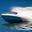

In [27]:
# Acessa a imagem de índice 1 do conjunto 'test_data'.
image = test_data[1]["image"]

# Exibe a variável 'image'.
image

In [28]:
# Aplica o pipeline sobre a variável 'image'.
pipe(image)

[{'label': 'FAKE', 'score': 0.9831088185310364},
 {'label': 'REAL', 'score': 0.01689114235341549}]

In [29]:
# Acessa o atributo "label" de um elemento específico de test_data.
# Serve para recuperar o rótulo real associado àquele exemplo de teste.
id2label[test_data[1]["label"]]

'FAKE'

In [33]:
!zip -r model_checkpoint.zip ../model/ai_vs_real_image_detection


  adding: ../model/ai_vs_real_image_detection/ (stored 0%)
  adding: ../model/ai_vs_real_image_detection/model.safetensors (deflated 7%)
  adding: ../model/ai_vs_real_image_detection/config.json (deflated 47%)
  adding: ../model/ai_vs_real_image_detection/checkpoint-2250/ (stored 0%)
  adding: ../model/ai_vs_real_image_detection/checkpoint-2250/trainer_state.json (deflated 67%)
  adding: ../model/ai_vs_real_image_detection/checkpoint-2250/scheduler.pt (deflated 49%)
  adding: ../model/ai_vs_real_image_detection/checkpoint-2250/model.safetensors (deflated 7%)
  adding: ../model/ai_vs_real_image_detection/checkpoint-2250/optimizer.pt (deflated 8%)
  adding: ../model/ai_vs_real_image_detection/checkpoint-2250/config.json (deflated 47%)
  adding: ../model/ai_vs_real_image_detection/checkpoint-2250/rng_state.pth (deflated 28%)
  adding: ../model/ai_vs_real_image_detection/checkpoint-2250/preprocessor_config.json (deflated 47%)
  adding: ../model/ai_vs_real_image_detection/checkpoint-2250/tr